## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with analyzing the data, developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Please read the instructions carefully before starting the project.**

**Note**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:

1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.

2. Switch to a different Google account and resume working on the project from there.

3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

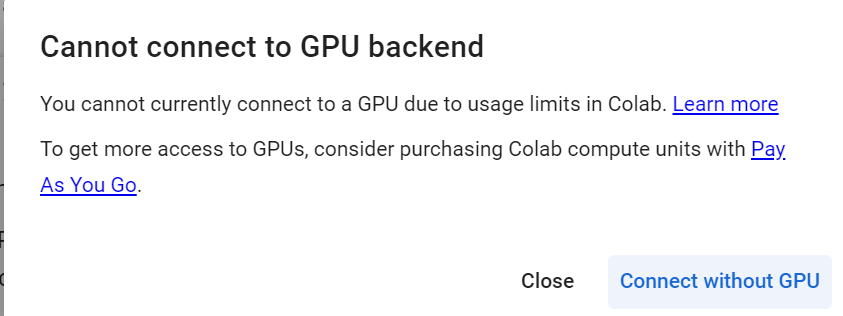

## **Installing and Importing Necessary Libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install -U sentence-transformers gensim transformers tqdm -q

In [2]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading the stock news dataset
stock_news = pd.read_csv("/content/drive/MyDrive/stock_news.csv")

In [ ]:
#Creating a copy of the dataset
stock = stock_news.copy()

## **Data Overview**

### Displaying the first few rows of the dataset

In [ ]:
stock.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1


###Checking the shape of the data

In [ ]:
stock.shape

(349, 8)

The dataset has 349 rows and 8 columns.

###Checking the data types of the columns

In [ ]:
stock.dtypes

,0
Date,object
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


All columns have the correct data types except for the date column. Let's convert the date column from an object to datetime format.

In [ ]:
stock['Date'] = pd.to_datetime(stock['Date'])

In [ ]:
stock.dtypes

,0
Date,datetime64[ns]
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


We could now see the date column is converted to datetime format

### Checking the statistical summary

In [ ]:
stock.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


**Date:** 349 entries from January 2, 2019, to April 30, 2019.

**Open:** Average price of 46.23, with a range from 37.57 to 66.82.

**High:** Average of 46.70, with a range from 37.82 to 67.06.

**Low:** Average of 45.75, ranging from 37.31 to 65.86.

**Close:** Average of 44.93, ranging from 36.25 to 64.81.

**Volume:** Average volume of 128.95 million, ranging from 45.45 to 244.44 million shares.

**Label:** Average of -0.05, with a range from -1 to 1, indicating slight negative overall movement.


The stock shows significant variation in prices and trading volume, with occasional large price movements

### Checking the duplicate values

In [ ]:
stock.duplicated().sum()

0

No Duplicate values exists in the dataset

### Checking for Missing values

In [ ]:
stock.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


No Missing values exists in the dataset

## **Exploratory Data Analysis**

### Univariate Analysis

* Distribution of individual variables
* Compute and check the distribution of the length of news content

### Observations on Label

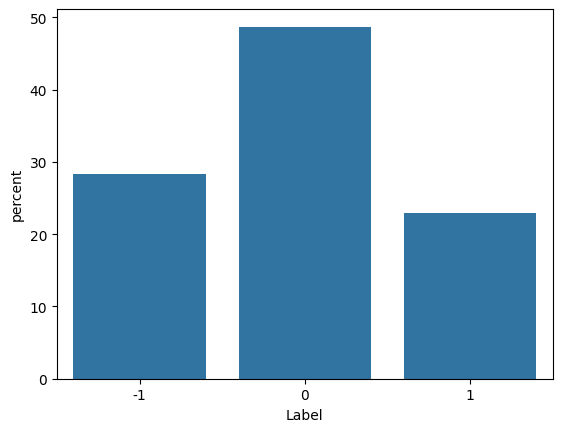

In [ ]:
sns.countplot(data=stock, x="Label", stat="percent");

The neutral polarity of the new content is the most prevalent, followed by negative, and then positive.

#### Density Plot of Price (Open,High,Low,Close)

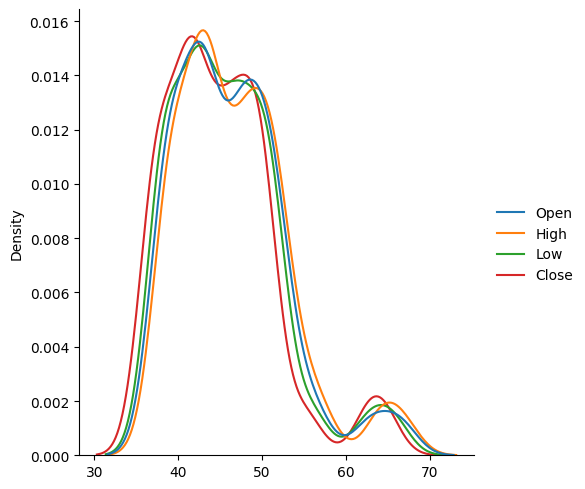

In [ ]:
sns.displot(data=stock[["Open","High","Low","Close"]], kind="kde", palette="tab10");

The density plot shows that mid-range stock prices are the most prevalent, with fewer occurrences at extreme low or high values.
The distributions of Open, High, Low, and Close are closely aligned, suggesting minimal variation between these metrics.

#### Observations on Volume

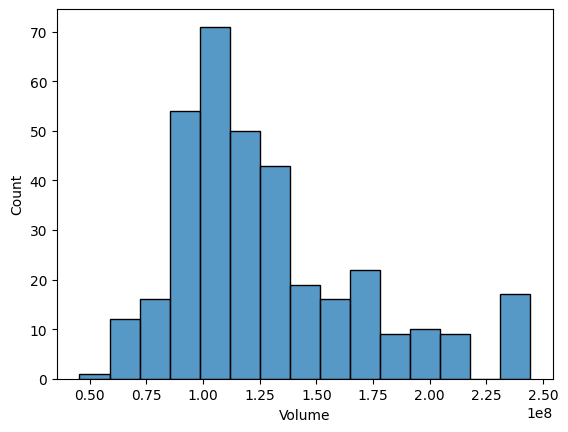

In [ ]:
sns.histplot(stock, x='Volume');

The distribution is slightly skewed to the right, indicating fewer occurrences of very high trading volumes.

#### Observations on News Length

In [ ]:
#Calculating the total number of words present in the news content.
stock['news_len'] = stock['News'].apply(lambda x: len(x.split(' ')))

# Statistical summary for the news content length
stock['news_len'].describe()

,news_len
count,349.000000
mean,49.312321
std,5.727770
min,19.000000
25%,46.000000
50%,50.000000
75%,53.000000
max,61.000000



The news_len column has 349 entries with an average length of 49.31 words/characters. It ranges from 19 to 61, with a standard deviation of 5.73, showing moderate variation. Most news items are between 46 and 53 words long.

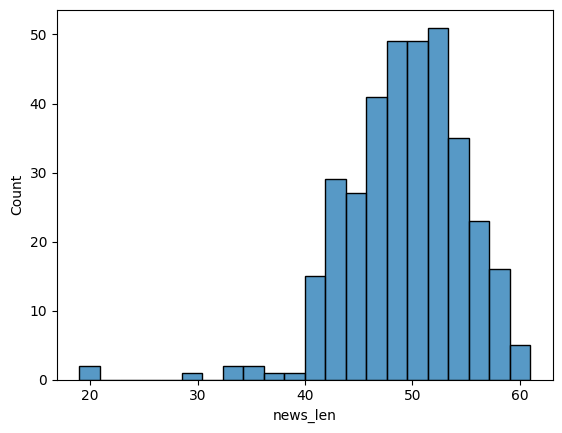

In [ ]:
# Histogram plot of news_len column

sns.histplot(data=stock,x="news_len");

***Central Tendency:*** The majority of news_len values cluster around 50, indicating that most news items have a similar length.
**Outliers:** A few data points lie below 40 and above 60, suggesting the presence of shorter or longer news items compared to the central range.

### Bivariate Analysis

* Correlation
* Sentiment Polarity vs Price
* Date vs Price

**Note**: The above points are listed to provide guidance on how to approach bivariate analysis. Analysis has to be done beyond the above listed points to get maximum scores.

## Correlation

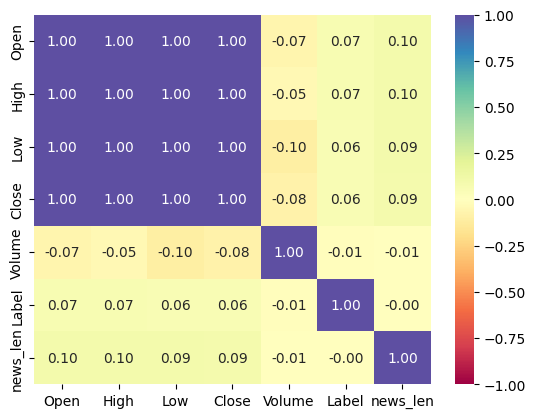

In [ ]:
sns.heatmap(
    stock.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

Open, High, Low, and Close are perfectly correlated (correlation = 1.00).
Volume has a weak negative correlation with price-related variables and negligible correlation with others.

The prices are perfectly correlated – likely due to the minimal variation between different prices.
There is a negative correlation, although very weak, between volume and prices – possibly resulting from selling pressure during periods of negative sentiment.

#### Label vs Price (Open, High, Low, Close)

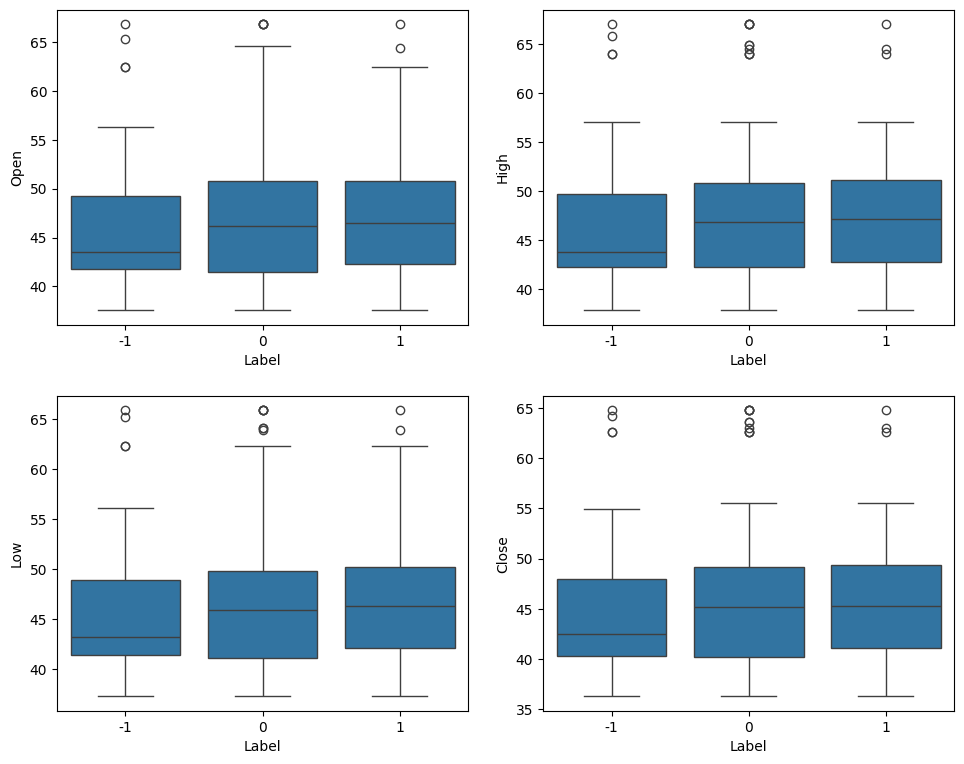

In [ ]:
plt.figure(figsize=(10, 8))

for i, variable in enumerate(['Open', 'High', 'Low', 'Close']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=stock, x="Label", y=variable)
    plt.tight_layout(pad=2)

plt.show()

The distributions of Open, High, Low, and Close are fairly similar across all Label categories, with overlapping ranges and medians.
Outliers are present in all features across all Label categories, particularly above the upper whisker.
There is no significant difference in the spread (interquartile range) of the features across the Label categories.

#### Label vs Volume

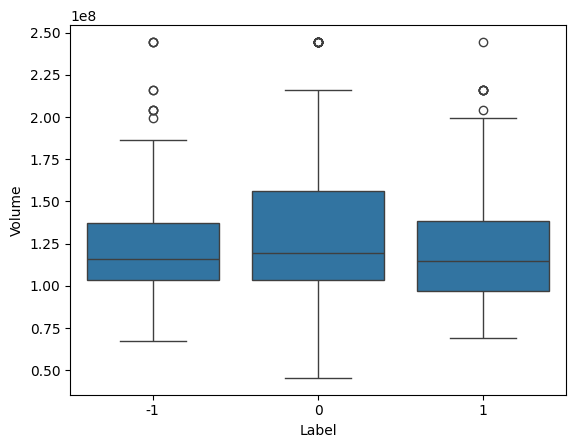

In [ ]:
sns.boxplot(
    data=stock, x="Label", y="Volume"
);

Volume is slightly higher for Label = 0 compared to others.
All categories have similar distributions with outliers present above.

#### Date vs Price (Open, High, Low, Close)

In [ ]:
stock_daily = stock.groupby('Date').agg(
    {
        'Open': 'mean',
        'High': 'mean',
        'Low': 'mean',
        'Close': 'mean',
        'Volume': 'mean',
    }
).reset_index()  # Group the 'stocks' DataFrame by the 'Date' column

stock_daily.set_index('Date', inplace=True)
stock_daily.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,41.740002,42.244999,41.482498,40.246914,130672400.0
2019-01-03,43.570000,43.787498,43.222500,42.470604,103544800.0
2019-01-04,47.910000,47.919998,47.095001,46.419842,111448000.0
2019-01-07,50.792500,51.122501,50.162498,49.110790,109012000.0
2019-01-08,53.474998,54.507500,51.685001,50.787209,216071600.0


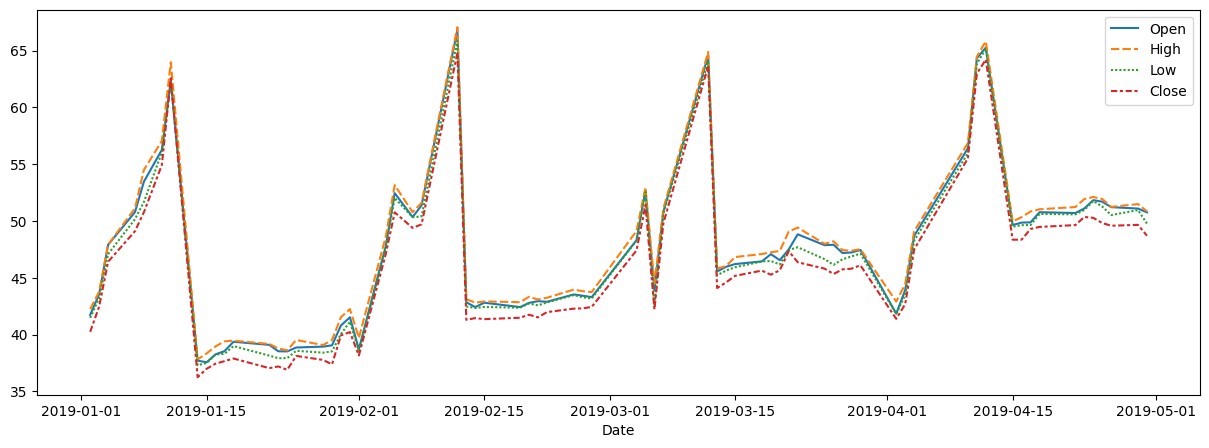

In [ ]:
plt.figure(figsize=(15,5))
sns.lineplot(stock_daily.drop("Volume", axis=1));

Periodic Spikes: There are consistent, sharp spikes in stock prices at regular intervals, indicating periods of high volatility.

Tight Grouping: The "Open," "High," "Low," and "Close" prices are closely aligned, showing minimal variation within daily trading ranges, except during spikes.

Downward Corrections: After each spike, there is a significant drop in all price levels, followed by a stabilization phase.

General Uptrend: The overall trend suggests a gradual increase in prices over time, despite the volatility.

Repetition of Patterns: The recurring spike-drop-stabilize pattern indicates cyclical or event-driven market behavior.


#### Volume vs Close Price

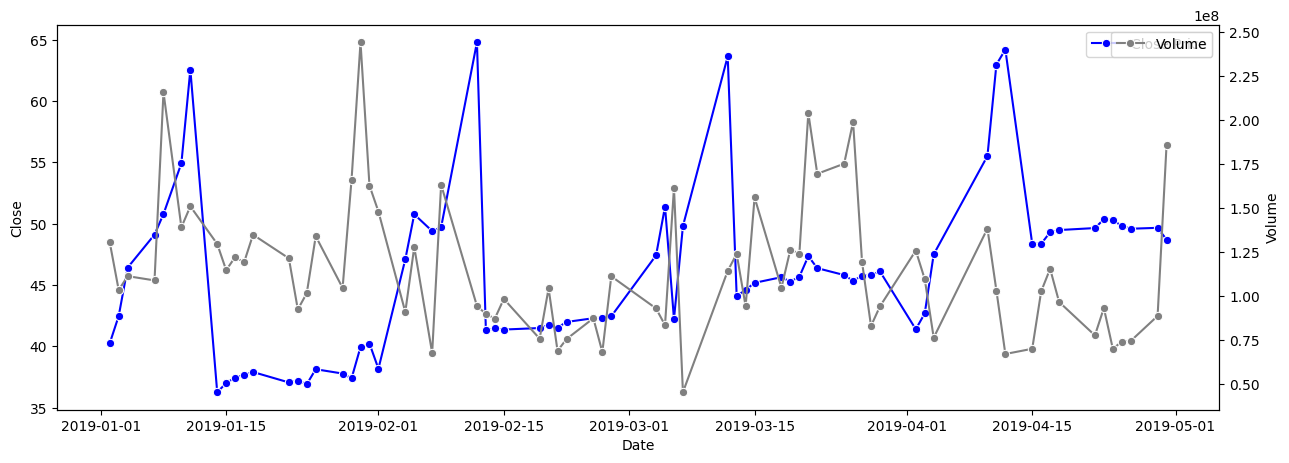

In [ ]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(15,5))

# Lineplot on primary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Close', ax=ax1, color='blue', marker='o', label='Close Price')

# Create a secondary y-axis
ax2 = ax1.twinx()

# Lineplot on secondary y-axis
sns.lineplot(data=stock_daily.reset_index(), x='Date', y='Volume', ax=ax2, color='gray', marker='o', label='Volume')

ax1.legend(bbox_to_anchor=(1,1));


Spikes in trading volume often match peaks in the closing price.
Both volume and price show regular sharp rises followed by drops.
Most of the time, volume stays steady with occasional surges.
Price and volume stabilize after each spike.

## **Data Preprocessing**

In [ ]:
stock["Date"].describe()

,Date
count,349
mean,2019-02-16 16:05:30.085959936
min,2019-01-02 00:00:00
25%,2019-01-14 00:00:00
50%,2019-02-05 00:00:00
75%,2019-03-22 00:00:00
max,2019-04-30 00:00:00


### Train-test-validation Split

In [ ]:
X_train = stock[(stock['Date'] < '2019-04-01')].reset_index()    # Select rows where 'Date' is before '2019-04-01'
X_val = stock[(stock['Date'] >= '2019-04-01') & (stock['Date'] < '2019-04-16')].reset_index()    # Select rows where 'Date' is from '2019-04-01' to '2019-04-16' (excluded)
X_test = stock[stock['Date'] >= '2019-04-16'].reset_index()    # Select rows where 'Date' is from '2019-04-16' till the end

In [ ]:
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (286, 10)
Validation data shape (21, 10)
Test data shape  (42, 10)
Train label shape (286,)
Validation label shape (21,)
Test label shape  (42,)


## **Word Embeddings**

### Word2Vec

In [ ]:
# Creating a list of all words in our data
words_list = [item.split(" ") for item in stock['News'].values]


In [ ]:
# Creating an instance of Word2Vec
vec_size = 300
model_W2V = Word2Vec(words_list, vector_size = vec_size, min_count = 1, window=5, workers = 6)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(list(model_W2V.wv.key_to_index)))

Length of the vocabulary is 4682


Let's check out a few word embeddings obtained using the model.

In [ ]:
# Checking the word embedding of a random word
word = "stock"
model_W2V.wv[word]

array([ 0.00327047,  0.04412288,  0.00541667,  0.02416475, -0.00313604,
       -0.05095255,  0.0354134 ,  0.08477473,  0.00965076, -0.01542701,
        0.0117057 , -0.02237522,  0.00131886,  0.01220702, -0.02955226,
       -0.02551682,  0.02113881, -0.01264445, -0.00219698, -0.01355164,
       -0.02691391,  0.00279639,  0.03729087,  0.00752717,  0.01481633,
        0.00594621, -0.0443792 ,  0.00636132, -0.01836282, -0.03561916,
        0.01412759, -0.02180975,  0.00342136, -0.00295949, -0.00463181,
        0.01699612,  0.01732159, -0.03855963,  0.0017264 , -0.01070158,
       -0.01631455, -0.0015589 , -0.00170739, -0.02634795,  0.01597724,
        0.04034942,  0.00023779,  0.01058463, -0.00181407,  0.02733617,
        0.02037743,  0.00535817, -0.01665496,  0.01307757, -0.01078495,
        0.02771504,  0.01366764,  0.00368458,  0.01601492, -0.00489103,
       -0.00680783, -0.01618506, -0.00021114,  0.01083652,  0.00655559,
        0.01460564,  0.00181665,  0.01493297, -0.02274986, -0.00

In [ ]:
# Checking the word embedding of a random word
word = "economy"
model_W2V.wv[word]

array([ 2.42804457e-03,  6.32035267e-03, -3.78400864e-06,  3.52860033e-03,
       -2.43939552e-03, -8.52898136e-03,  8.49327166e-03,  1.54960603e-02,
        4.09148895e-04, -1.37133629e-03,  2.43468909e-03, -4.51360317e-03,
        7.45525234e-04,  2.02096859e-03, -4.82105743e-03, -3.27660935e-03,
        2.24151812e-03, -3.33042350e-03, -6.10007439e-04, -3.86203406e-03,
       -1.16187858e-03,  1.66671700e-03,  5.11995656e-03,  2.29434739e-03,
        4.55290964e-03,  1.57099217e-03, -4.46641492e-03, -1.35847740e-03,
       -2.44673528e-03, -5.64169791e-03,  2.96606938e-03, -2.04876368e-03,
        3.14603443e-03, -1.71469129e-03,  2.05445598e-04,  3.53647931e-03,
        1.45844172e-03, -2.91425921e-03,  5.45735296e-04, -1.79717585e-03,
       -4.70417971e-03,  5.31324651e-04,  1.35510648e-03, -5.12811448e-03,
       -1.08295924e-03,  6.74435263e-03, -1.65648281e-03,  5.00212004e-03,
       -2.81798444e-03,  5.82754891e-03,  6.69114524e-04, -1.22838770e-04,
       -2.27301940e-03,  

In [ ]:
# Retrieving the words present in the Word2Vec model's vocabulary
words = list(model_W2V.wv.key_to_index.keys())

# Retrieving word vectors for all the words present in the model's vocabulary
wvs = model_W2V.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, wvs))

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

X_train_wv = pd.DataFrame(X_train["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_wv = pd.DataFrame(X_val["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_wv = pd.DataFrame(X_test["News"].apply(average_vectorizer_Word2Vec).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  0.8863067626953125


In [ ]:
print(X_train_wv.shape, X_val_wv.shape, X_test_wv.shape)

(286, 300) (21, 300) (42, 300)


##GloVe

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2024-11-22 00:02:41--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2024-11-22 00:02:41--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2024-11-22 00:02:41--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
from gensim.scripts.glove2word2vec import glove2word2vec

# Convert the GloVe file (glove.6B.100d.txt) to Word2Vec format
input_file = 'glove.6B.100d.txt'  # original GloVe file
output_file = 'glove.6B.100d.txt.word2vec'  # output word2vec formatted file

glove2word2vec(input_file, output_file)

(400000, 100)

In [ ]:
# load the Stanford GloVe model
filename = 'glove.6B.100d.txt.word2vec'
glove_model = KeyedVectors.load_word2vec_format(filename, binary=False)

In [ ]:
# Checking the size of the vocabulary
print("Length of the vocabulary is", len(glove_model.index_to_key))

Length of the vocabulary is 400000


Let's check out a few word embeddings.


In [ ]:
# Checking the word embedding of a random word
word = "stock"
glove_model[word]

array([ 8.6341e-01,  6.9648e-01,  4.5794e-02, -9.5708e-03, -2.5498e-01,
       -7.4666e-01, -2.2086e-01, -4.4615e-01, -1.0423e-01, -9.9931e-01,
        7.2550e-02,  4.5049e-01, -5.9912e-02, -5.7837e-01, -4.6540e-01,
        4.3429e-02, -5.0570e-01, -1.5442e-01,  9.8250e-01, -8.1571e-02,
        2.6523e-01, -2.3734e-01,  9.7675e-02,  5.8588e-01, -1.2948e-01,
       -6.8956e-01, -1.2811e-01, -5.2265e-02, -6.7719e-01,  3.0190e-02,
        1.8058e-01,  8.6121e-01, -8.3206e-01, -5.6887e-02, -2.9578e-01,
        4.7180e-01,  1.2811e+00, -2.5228e-01,  4.9557e-02, -7.2455e-01,
        6.6758e-01, -1.1091e+00, -2.0493e-01, -5.8669e-01, -2.5375e-03,
        8.2777e-01, -4.9102e-01, -2.6475e-01,  4.3015e-01, -2.0516e+00,
       -3.3208e-01,  5.1845e-02,  5.2646e-01,  8.7452e-01, -9.0237e-01,
       -1.7366e+00, -3.4727e-01,  1.6590e-01,  2.7727e+00,  6.5756e-02,
       -4.0363e-01,  3.8252e-01, -3.0787e-01,  5.9202e-01,  1.3468e-01,
       -3.3851e-01,  3.3646e-01,  2.0950e-01,  8.5905e-01,  5.18

In [ ]:
# Checking the word embedding of a random word
word = "economy"
glove_model[word]

array([-0.19382  ,  1.017    ,  1.076    ,  0.02954  , -0.39192  ,
       -1.3891   , -0.87873  , -0.63162  ,  0.9643   , -0.43035  ,
       -0.34868  ,  0.22736  , -0.40296  ,  0.15641  , -0.16813  ,
       -0.15343  , -0.15799  , -0.27612  ,  0.18088  , -0.28386  ,
        0.49847  ,  0.29864  ,  0.32353  ,  0.18108  , -0.59623  ,
       -0.54165  , -0.70019  , -0.64956  , -0.69063  ,  0.18084  ,
       -0.38581  ,  0.56086  , -0.40313  , -0.38777  , -0.70615  ,
        0.20657  ,  0.34171  , -0.23393  , -0.35882  , -0.2201   ,
       -0.76182  , -1.2047   ,  0.4339   ,  1.1656   ,  0.1836   ,
       -0.21601  ,  0.93198  , -0.059616 , -0.11624  , -1.3259   ,
       -0.79772  , -0.0074957, -0.0889   ,  1.4749   ,  0.31157  ,
       -2.2952   , -0.058351 ,  0.39353  ,  1.4983   ,  0.74023  ,
       -0.20109  ,  0.098124 , -0.73081  , -0.32294  ,  0.16703  ,
        0.87431  , -0.041624 , -0.51022  ,  1.0737   , -0.4257   ,
        1.0581   ,  0.19859  , -0.60087  , -0.33906  ,  0.6024

In [ ]:
# Retrieving the words present in the GloVe model's vocabulary
glove_words = glove_model.index_to_key

# Creating a dictionary of words and their corresponding vectors
glove_word_vector_dict = dict(zip(glove_model.index_to_key,list(glove_model.vectors)))

In [ ]:
vec_size=100

In [ ]:
def average_vectorizer_GloVe(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in glove_words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(glove_word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
start = time.time()

# Apply the GloVe vectorizer to the 'News' column of each dataset
X_train_gl = pd.DataFrame(X_train["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_val_gl = pd.DataFrame(X_val["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])
X_test_gl = pd.DataFrame(X_test["News"].apply(average_vectorizer_GloVe).tolist(), columns=['Feature '+str(i) for i in range(vec_size)])

end = time.time()
print('Time taken ', (end-start))

Time taken  35.409902811050415


In [ ]:
print(X_train_gl.shape, X_val_gl.shape, X_test_gl.shape)

(286, 100) (21, 100) (42, 100)


### Sentence Transformer

#### Defining the model

In [ ]:
#Defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Encoding the dataset

In [ ]:
# setting the device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
start = time.time()

X_train_st = model.encode(X_train["News"].values, show_progress_bar=True, device=device)  # Apply Sentence Transformer on 'News' column
X_val_st = model.encode(X_val["News"].values, show_progress_bar=True, device=device)  # Apply Sentence Transformer on 'News' column
X_test_st = model.encode(X_test["News"].values, show_progress_bar=True, device=device)  # Apply Sentence Transformer on 'News' column

end = time.time()
print("Time taken ", (end-start))

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Time taken  5.068006753921509


In [ ]:
print(X_train_st.shape, X_val_st.shape, X_test_st.shape)

(286, 384) (21, 384) (42, 384)



Each news content has been converted to a 384-dimensional vector.

## **Sentiment Analysis**

### Model Evaluation Criterion

### Utility Functions

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    cm = confusion_matrix(target, pred)  # Compute the confusion matrix.

    plt.figure(figsize=(5, 4))  # Create a new figure with a specified size.
    label_list = [0, 1,-1]  # Define the labels for the confusion matrix.
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    # Plot the confusion matrix using a heatmap with annotations.

    plt.ylabel('Actual')  # Label for the y-axis.
    plt.xlabel('Predicted')  # Label for the x-axis.
    plt.title('Confusion Matrix')  # Title of the plot.
    plt.show()  # Display the plot.

In [ ]:
def model_performance_classification_sklearn(model, predictors, target):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """
    pred = model.predict(predictors)  # Make predictions using the classifier.

    acc = accuracy_score(target, pred)  # Compute Accuracy.
    recall = recall_score(target, pred,average='weighted')  # Compute Recall.
    precision = precision_score(target, pred,average='weighted')  # Compute Precision.
    f1 = f1_score(target, pred,average='weighted')  # Compute F1-score.

    # Create a DataFrame to store the computed metrics.
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf  # Return the DataFrame with the metrics.

### Base Model - Word2Vec

In [ ]:
# Building the model

base_wv = RandomForestClassifier(random_state=42)
# Fitting on train data
base_wv.fit(X_train_wv, y_train)

RandomForestClassifier(random_state=42)

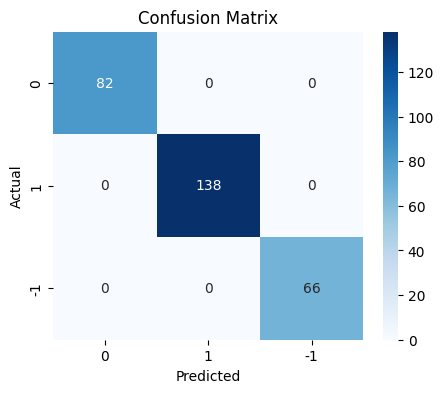

In [ ]:
plot_confusion_matrix(base_wv,X_train_wv,y_train)

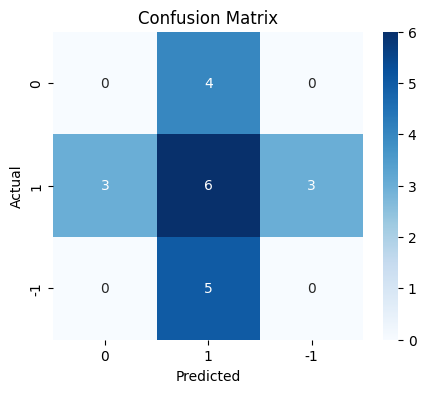

In [ ]:
plot_confusion_matrix(base_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
base_train_wv = model_performance_classification_sklearn(base_wv,X_train_wv,y_train)
print("Training performance:\n", base_train_wv)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
#Calculating different metrics on validation data
base_val_wv = model_performance_classification_sklearn(base_wv,X_val_wv,y_val)
print("Validation performance:\n",base_val_wv)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.285714  0.285714   0.228571  0.253968


### Base Model - GloVe

In [ ]:
base_wv = RandomForestClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_gl, y_train)

RandomForestClassifier(random_state=42)

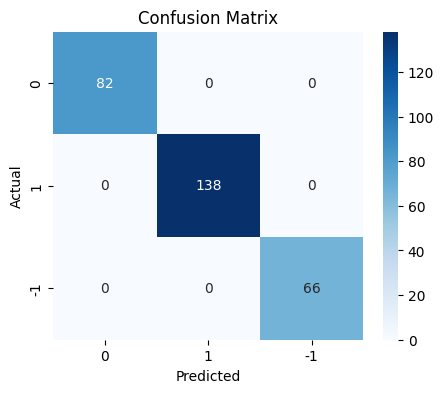

In [ ]:
plot_confusion_matrix(base_wv, X_train_gl, y_train)

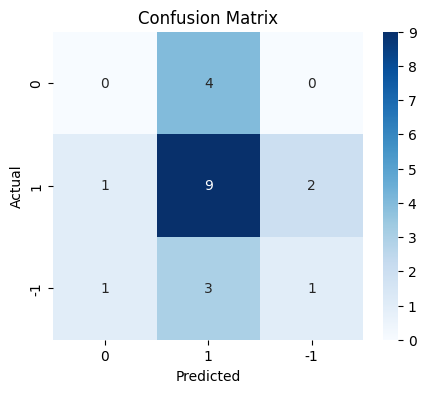

In [ ]:
plot_confusion_matrix(base_wv, X_val_gl, y_val)

In [ ]:
# Calculating different metrics on training data
base_train_gl = model_performance_classification_sklearn(base_wv, X_train_gl, y_train)
print("Training performance:\n", base_train_gl)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
base_val_gl = model_performance_classification_sklearn(base_wv, X_val_gl, y_val)
print("Validation performance:\n", base_val_gl)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.400794  0.426871


### Base Model - Sentence Transformer

In [ ]:
base_wv = RandomForestClassifier(random_state=42)

# Fitting on train data
base_wv.fit(X_train_st, y_train)

RandomForestClassifier(random_state=42)

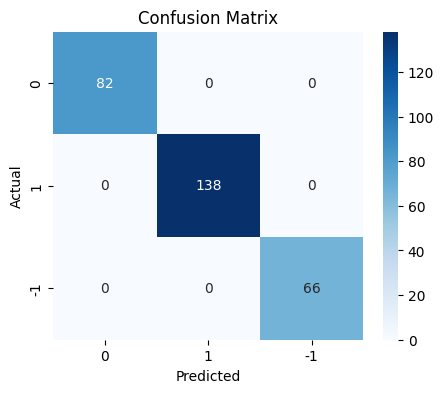

In [ ]:
plot_confusion_matrix(base_wv, X_train_st, y_train)

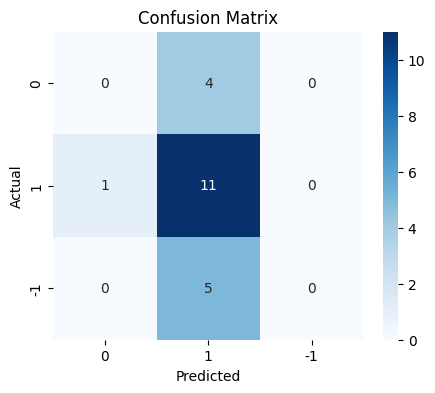

In [ ]:
plot_confusion_matrix(base_wv, X_val_st, y_val)

In [ ]:
# Calculating different metrics on training data
base_train_st = model_performance_classification_sklearn(base_wv, X_train_st, y_train)
print("Training performance:\n", base_train_st)

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
base_val_st = model_performance_classification_sklearn(base_wv, X_val_st, y_val)
print("Validation performance:\n", base_val_st)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.52381  0.52381   0.314286  0.392857


### Tuned Model - Word2Vec

In [ ]:
start = time.time()

tuned_wv = RandomForestClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_wv, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_wv = grid_obj.best_estimator_

Time taken  162.02095484733582


In [ ]:
# Fit the best algorithm to the data.
tuned_wv.fit(X_train_wv, y_train)

RandomForestClassifier(max_depth=6, max_features=0.4, min_samples_split=9,
                       random_state=42)

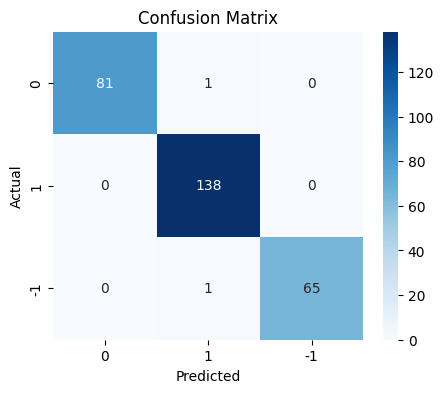

In [ ]:
plot_confusion_matrix(tuned_wv,X_train_wv,y_train)

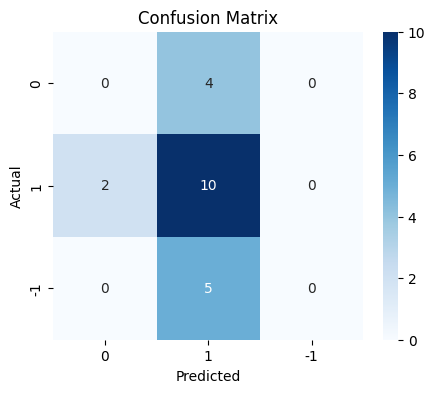

In [ ]:
plot_confusion_matrix(tuned_wv,X_val_wv,y_val)

In [ ]:
#Calculating different metrics on training data
tuned_train_wv=model_performance_classification_sklearn(tuned_wv,X_train_wv,y_train)
print("Training performance:\n",tuned_train_wv)

Training performance:
    Accuracy   Recall  Precision        F1
0   0.98951  0.98951   0.989653  0.989424


In [ ]:
#Calculating different metrics on validation data
tuned_val_wv = model_performance_classification_sklearn(tuned_wv,X_val_wv,y_val)
print("Validation performance:\n",tuned_val_wv)

Validation performance:
    Accuracy   Recall  Precision        F1
0   0.47619  0.47619   0.300752  0.368664


### Tuned Model - GloVe

In [ ]:
start = time.time()

tuned_wv = RandomForestClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_gl, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_gl = grid_obj.best_estimator_

Time taken  102.95606327056885


In [ ]:
tuned_gl.fit(X_train_gl, y_train)

RandomForestClassifier(max_depth=6, max_features=0.2, min_samples_split=7,
                       random_state=42)

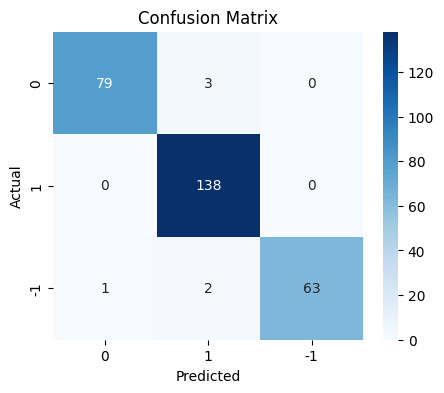

In [ ]:
plot_confusion_matrix(tuned_gl, X_train_gl, y_train)

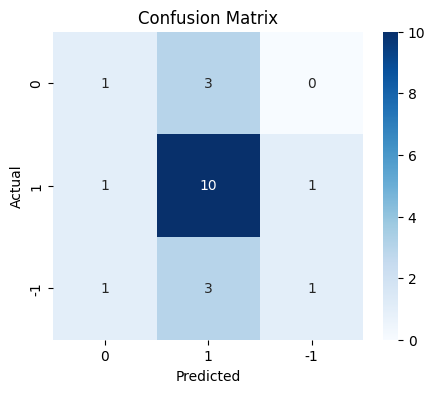

In [ ]:
plot_confusion_matrix(tuned_gl, X_val_gl, y_val)

In [ ]:
tuned_train_gl = model_performance_classification_sklearn(tuned_gl, X_train_gl, y_train)
print("Training performance:\n", tuned_train_gl)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.979021  0.979021   0.979545  0.978968


In [ ]:
tuned_val_gl = model_performance_classification_sklearn(tuned_gl, X_val_gl, y_val)
print("Validation performance:\n", tuned_val_gl)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.539683  0.530612


### Tuned Model - Sentence Transformer

In [ ]:
start = time.time()

tuned_wv = RandomForestClassifier(random_state=42)


parameters = {
    'max_depth': np.arange(3,7),
    'min_samples_split': np.arange(5,12,2),
    'max_features': ['log2', 'sqrt', 0.2, 0.4]
}

# Run the grid search
grid_obj = GridSearchCV(tuned_wv, parameters, scoring='f1_weighted',cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train_st, y_train)

end = time.time()
print("Time taken ",(end-start))

# Set the clf to the best combination of parameters
tuned_st = grid_obj.best_estimator_

Time taken  181.24588346481323


In [ ]:
tuned_st.fit(X_train_st, y_train)

RandomForestClassifier(max_depth=5, max_features=0.4, min_samples_split=9,
                       random_state=42)

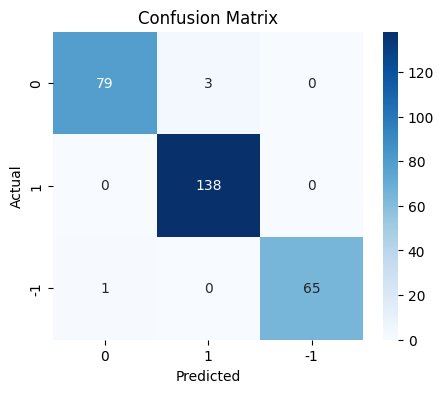

In [ ]:
plot_confusion_matrix(tuned_st, X_train_st, y_train)

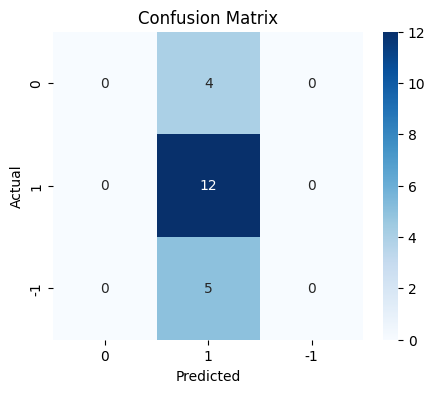

In [ ]:
plot_confusion_matrix(tuned_st, X_val_st, y_val)

In [ ]:
tuned_train_st = model_performance_classification_sklearn(tuned_st, X_train_st, y_train)
print("Training performance:\n", tuned_train_st)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.986014  0.986014    0.98615  0.985971


In [ ]:
tuned_val_st = model_performance_classification_sklearn(tuned_st, X_val_st, y_val)
print("Validation performance:\n", tuned_val_st)

Validation performance:
    Accuracy    Recall  Precision        F1
0  0.571429  0.571429   0.326531  0.415584


### Model Performance Summary and Final Model Selection

In [ ]:
#training performance comparison

models_train_comp_df = pd.concat(
    [base_train_wv.T,
     base_train_gl.T,
     base_train_st.T,
     tuned_train_wv.T,
     tuned_train_gl.T,
     tuned_train_st.T,
    ],axis=1
)

models_train_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,1.0,1.0,1.0,0.989510,0.979021,0.986014
Recall,1.0,1.0,1.0,0.989510,0.979021,0.986014
Precision,1.0,1.0,1.0,0.989653,0.979545,0.986150
F1,1.0,1.0,1.0,0.989424,0.978968,0.985971


In [ ]:
#validation performance comparison

models_val_comp_df = pd.concat(
    [base_val_wv.T,
     base_val_gl.T,
     base_val_st.T,
     tuned_val_wv.T,
     tuned_val_gl.T,
     tuned_val_st.T,
     ],axis=1
)

models_val_comp_df.columns = [
    "Base Model (Word2Vec)",
    "Base Model (GloVe)",
    "Base Model (Sentence Transformer)",
    "Tuned Model (Word2Vec)",
    "Tuned Model (GloVe)",
    "Tuned Model (Sentence Transformer)",
]

print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Base Model (Word2Vec),Base Model (GloVe),Base Model (Sentence Transformer),Tuned Model (Word2Vec),Tuned Model (GloVe),Tuned Model (Sentence Transformer)
Accuracy,0.285714,0.476190,0.523810,0.476190,0.571429,0.571429
Recall,0.285714,0.476190,0.523810,0.476190,0.571429,0.571429
Precision,0.228571,0.400794,0.314286,0.300752,0.539683,0.326531
F1,0.253968,0.426871,0.392857,0.368664,0.530612,0.415584


The Tuned Sentence Transformer model performs the best, with the highest accuracy and a good balance of recall, precision, and F1 score on the validation data. It generalizes well, making it the optimal choice compared to the other models.

### Model Performance Check on Test Data

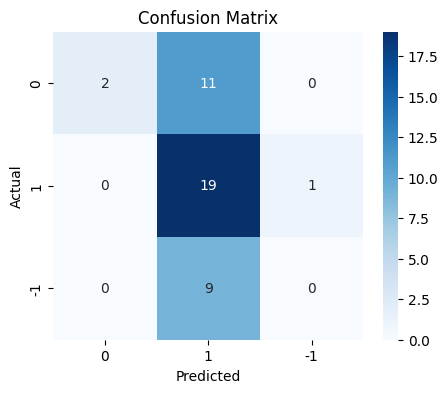

In [ ]:
plot_confusion_matrix(tuned_st, X_test_st, y_test)

In [ ]:
final_model_test = model_performance_classification_sklearn(tuned_st, X_test_st, y_test)
print("Test performance for the final model:\n", final_model_test)

Test performance for the final model:
    Accuracy  Recall  Precision        F1
0       0.5     0.5   0.541514  0.389239


The final model's test performance indicates moderate accuracy and recall at 50%, with a slightly higher precision (54%) but a low F1 score (39%).

## **Weekly News Summarization**

**Important Note**: It is recommended to run this section of the project independently from the previous sections in order to avoid runtime crashes due to RAM overload.

#### Installing and Importing the necessary libraries

In [1]:
!pip install --upgrade pip setuptools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.2 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.1.0
    Uninstalling setuptools-75.1.0:
      Successfully uninstalled setuptools-75.1.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [1]:
!apt-get update
!apt-get install -y build-essential
!apt-get install -y nvidia-cuda-toolkit

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,172 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,618 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [3,323 kB]
Get:13 http://archive.ubuntu.c

In [2]:
!pip install llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 MB 44.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.2-cp310-cp310-linux_x86_64.whl size=3410026 sha256=a9af7c31025eba139ded35bcc7e8c5ded3c9cbf008404561035ea731f0461a0a
  Stored in directory: /root/.cache/pip/wheels/49/1c/f0/6c1ed6032d5827dea28df8a8df860d90ca1bcd7b3fa455f5e1
Successfully built llama-cpp-python


In [3]:
# Installation for GPU llama-cpp-python
# uncomment and run the following code in case GPU is being used
!CMAKE_ARGS="-DLLAMA_CUBLAS=on -DCMAKE_BUILD_TYPE=Release" FORCE_CMAKE=1 pip install --upgrade --no-cache-dir llama-cpp-python -q

# Installation for CPU llama-cpp-python
# uncomment and run the following code in case GPU is not being used
#!CMAKE_ARGS="-DLLAMA_CUBLAS=off" FORCE_CMAKE=1 pip install llama-cpp-python -q

In [4]:
# Function to download the model from the Hugging Face model hub
from huggingface_hub import hf_hub_download

# Importing the Llama class from the llama_cpp module
from llama_cpp import Llama

# Importing the library for data manipulation
import pandas as pd

from tqdm import tqdm # For progress bar related functionalities
tqdm.pandas()

#### Loading the data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
stock_news = pd.read_csv("/content/drive/MyDrive/stock_news.csv")

In [7]:
data = stock_news.copy()

#### Loading the model

In [8]:
model_name_or_path = "TheBloke/Mistral-7B-Instruct-v0.2-GGUF"
model_basename = "mistral-7b-instruct-v0.2.Q6_K.gguf"


model_path = hf_hub_download(
    repo_id=model_name_or_path,
    filename=model_basename
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


mistral-7b-instruct-v0.2.Q6_K.gguf:   0%|          | 0.00/5.94G [00:00<?, ?B/s]

In [9]:
llm = Llama(
    model_path=model_path, # Path to the model
    n_gpu_layers=100, #Number of layers transferred to GPU
    n_ctx=4500, #Context window
)

llama_model_loader: loaded meta data with 24 key-value pairs and 291 tensors from /root/.cache/huggingface/hub/models--TheBloke--Mistral-7B-Instruct-v0.2-GGUF/snapshots/3a6fbf4a41a1d52e415a4958cde6856d34b2db93/mistral-7b-instruct-v0.2.Q6_K.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = mistralai_mistral-7b-instruct-v0.2
llama_model_loader: - kv   2:                       llama.context_length u32              = 32768
llama_model_loader: - kv   3:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   4:                          llama.block_count u32              = 32
llama_model_loader: - kv   5:                  llama.feed_forward_length u32              = 14336
llama_model_loade

#### Aggregating the data weekly

In [10]:
data["Date"] = pd.to_datetime(data['Date'])  # Convert the 'Date' column to datetime format.

In [11]:
# Group the data by week using the 'Date' column.
weekly_grouped = data.groupby(pd.Grouper(key='Date', freq='W'))

In [12]:
weekly_grouped = weekly_grouped.agg(
    {
        'News': lambda x: ' || '.join(x)  # Join the news values with ' || ' separator.
    }
).reset_index()

print(weekly_grouped.shape)

(18, 2)


In [13]:
weekly_grouped

,Date,News
0,2019-01-06,The tech sector experienced a significant dec...
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...
2,2019-01-20,The U.S. stock market declined on Monday as c...
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre..."
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...
5,2019-02-10,"The Dow Jones Industrial Average, S&P 500, an..."
6,2019-02-17,"This week, the European Union's second highes..."
7,2019-02-24,This news article discusses progress towards ...
8,2019-03-03,The Dow Jones Industrial Average and other ma...
9,2019-03-10,"Spotify, the world's largest paid music strea..."


In [14]:
# creating a copy of the data
data_1 = weekly_grouped.copy()

#### Summarization

**Note**:

- The model is expected to summarize the news from the week by identifying the top three positive and negative events that are most likely to impact the price of the stock.

- As an output, the model is expected to return a JSON containing two keys, one for Positive Events and one for Negative Events.

For the project, we need to define the prompt to be fed to the LLM to help it understand the task to perform. The following should be the components of the prompt:

1. **Role**: Specifies the role the LLM will be taking up to perform the specified task, along with any specific details regarding the role

  - **Example**: `You are an expert data analyst specializing in news content analysis.`

2. **Task**: Specifies the task to be performed and outlines what needs to be accomplished, clearly defining the objective

  - **Example**: `Analyze the provided news headline and return the main topics contained within it.`

3. **Instructions**: Provides detailed guidelines on how to perform the task, which includes steps, rules, and criteria to ensure the task is executed correctly

  - **Example**:

```
Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.
```

4. **Output Format**: Specifies the format in which the final response should be structured, ensuring consistency and clarity in the generated output

  - **Example**: `Return the output in JSON format with keys as the topic number and values as the actual topic.`

**Full Prompt Example**:

```
You are an expert data analyst specializing in news content analysis.

Task: Analyze the provided news headline and return the main topics contained within it.

Instructions:
1. Read the news headline carefully.
2. Identify the main subjects or entities mentioned in the headline.
3. Determine the key events or actions described in the headline.
4. Extract relevant keywords that represent the topics.
5. List the topics in a concise manner.

Return the output in JSON format with keys as the topic number and values as the actual topic.
```

**Sample Output**:

`{"1": "Politics", "2": "Economy", "3": "Health" }`

##### Utility Functions

In [15]:
# defining a function to parse the JSON output from the model
def extract_json_data(json_str):
    import json
    try:
        # Find the indices of the opening and closing curly braces
        json_start = json_str.find('{')
        json_end = json_str.rfind('}')

        if json_start != -1 and json_end != -1:
            extracted_category = json_str[json_start:json_end + 1]  # Extract the JSON object
            data_dict = json.loads(extracted_category)
            return data_dict
        else:
            print(f"Warning: JSON object not found in response: {json_str}")
            return {}
    except json.JSONDecodeError as e:
        print(f"Error parsing JSON: {e}")
        return {}

##### Defining the response function

In [16]:
#Defining the response function
def response_mistral_1(prompt, news):
    model_output = llm(
      f"""
      [INST]
      {prompt}
      News Articles: {news}
      [/INST]
      """,
      max_tokens=400, #Complete the code to set the maximum number of tokens the model should generate for this task.
      temperature=0.05, #Complete the code to set the value for temperature.
      top_p=0.9, #Complete the code to set the value for top_p
      top_k=50, #Complete the code to set the value for top_k
      echo=False,
    )

    final_output = model_output["choices"][0]["text"]

    return final_output

##### Checking the model output on a sample

**Note**: Use this section to test out the prompt with one instance before using it for the entire weekly data.

In [17]:
news = data_1.loc[0, 'News']

In [18]:
print(len(news.split(' ')))
news

2611


' The tech sector experienced a significant decline in the aftermarket following Apple\'s Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple\'s downward revision of its revenue expectations for the quarter, previously announced in January. ||  Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple\'s stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10 ||  Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple\'s shares fell 8.5% in post market trading, while Asian suppliers like Hon ||  This news article reports that yields o

In [19]:
#Define the prompt for this task
prompt = """
    You are a news summarization model. Your task is to provide a concise summary of the news article that follows.
    Be objective and ensure the summary captures the most important points of the article.
    If the article includes multiple topics, try to cover all major aspects.
    Please summarize the following news article:

    News Article: {news}
"""


In [20]:
%%time
summary = response_mistral_1(prompt, news)
print(summary)

llama_perf_context_print:        load time = 1960642.82 ms
llama_perf_context_print: prompt eval time =       0.00 ms /  3841 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   270 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time = 2231487.67 ms /  4111 tokens


 apple's Q1 revenue missed analyst expectations, leading to a significant decline in Apple's stock price and negatively impacting related suppliers. Apple attributed the shortfall to weaker demand in China and fewer iPhone upgrades. The news caused concerns about a global economic slowdown, leading to a surge in the Japanese yen and a decline in the US dollar. Gold prices also rose as a safe haven asset. Apple's revenue warning came amid weak economic data from China and Europe, as well as the US-China trade tensions. The tech giant's suppliers, including Hon Hai Precision Industry, Taiwan Semiconductor Manufacturing Company, and LG Innotec, were also affected. The Australian dollar experienced significant volatility and plunged to multi-year lows against major currencies due to automated selling, liquidity issues, and a drought of trades. Oil prices also dropped due to investor sentiment remaining affected by China's economic slowdown and turmoil in stock and currency markets. Roku In

##### Checking the model output on the weekly data

In [ ]:
%%time
data_1['Key Events']=data_1['News'].progress_apply(lambda x:response_mistral_1(prompt,x))

  0%|          | 0/18 [00:00<?, ?it/s]Llama.generate: 3840 prefix-match hit, remaining 1 prompt tokens to eval
llama_perf_context_print:        load time = 1960642.82 ms
llama_perf_context_print: prompt eval time =       0.00 ms /     1 tokens (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:        eval time =       0.00 ms /   400 runs   (    0.00 ms per token,      inf tokens per second)
llama_perf_context_print:       total time =  398308.22 ms /   401 tokens
 11%|█         | 2/18 [06:38<53:06, 199.17s/it]Llama.generate: 96 prefix-match hit, remaining 2234 prompt tokens to eval


In [ ]:
data_1["Key Events"].head()

,Key Events
0,Apple's Q1 revenue warning led to a significa...
1,Sprint and Samsung plan to release 5G smartpho...
2,U.S. stocks experienced declines on Monday du...
3,The Swiss National Bank governor Andrea Maech...
4,Caterpillar reported lower-than-expected four...


##### Formatting the model output

In [ ]:
data_1['model_response_parsed'] = data_1['Key Events'].apply(extract_json_data)
data_1.head()

       
       Concerns
       U

       Apple's stock rose slightly in after hours trading despite reporting a rare revenue decline due to weak iPhone sales, particularly in China.

       Separately, Akamai Technologies reported stronger than projected earnings, driven by increased demand for its cybersecurity and media content delivery services. The company's cloud security business saw a 36% increase in revenue to $185 million, and is expected to exceed $1 billion in annual revenue soon (Akam
      2. WhatsApp security bug: The messaging app acknowledged a security issue that allows iPhone users to bypass its new privacy feature requiring Touch ID or Face ID for app access when selecting any interval other than immediate verification. A fix is in progress.
      3. Garmin's strong Q4 earnings: The company reported robust demand for wearable fitness
      
      AAC Technologies Holdings, an Apple supplier based in Hong Kong, reported a significant decrease in expected net profit fo

,Date,News,Key Events,model_response_parsed
0,2019-01-06,The tech sector experienced a significant dec...,Apple's Q1 revenue warning led to a significa...,{}
1,2019-01-13,Sprint and Samsung plan to release 5G smartph...,Sprint and Samsung plan to release 5G smartpho...,{}
2,2019-01-20,The U.S. stock market declined on Monday as c...,U.S. stocks experienced declines on Monday du...,{}
3,2019-01-27,"The Swiss National Bank (SNB) governor, Andre...",The Swiss National Bank governor Andrea Maech...,{}
4,2019-02-03,Caterpillar Inc reported lower-than-expected ...,Caterpillar reported lower-than-expected four...,{}


In [ ]:
model_response_parsed = pd.json_normalize(data_1['model_response_parsed'])
model_response_parsed.head()

In [ ]:
final_output = pd.concat([data_1.reset_index(drop=True),model_response_parsed],axis=1)
final_output.drop(['Key Events','model_response_parsed'], axis=1, inplace=True)
final_output.columns = ['Week End Date', 'News', 'Week Positive Events', 'Week Negative Events']

final_output.head()

## **Conclusions and Recommendations**

**Conclusions**

**Model Performance:**

**Training vs. Validation Performance:**
Models exhibit overfitting, with perfect scores (Accuracy, Recall, Precision, F1) on the training data but significantly lower performance on validation and test sets.
Word2Vec-based models perform the worst across all metrics, indicating their embeddings are less effective for this task.
GloVe-based models outperform Word2Vec and are marginally better than Sentence Transformer models on validation data.
Tuned Sentence Transformer achieves the best balance in validation, showing a promising combination of generalization and metric consistency.

**Test Performance:**

The final model's test performance is moderate, with 50% accuracy and recall, a slightly higher precision of ~54%, but a low F1 score of ~39%. This suggests limited generalizability to unseen data.
Insights from News Analysis:

Financial updates and events like Apple's revenue warnings and US-China trade tensions have significant impacts on market sentiment.
Positive developments (e.g., Spotify exceeding revenue expectations) and negative news (e.g., weaker iPhone sales) influence stock movements differently across industries.
Data and Workflow Observations:

The provided news dataset lacks structured JSON formatting, making preprocessing and analysis more challenging.
GloVe embeddings enhance the ability to derive domain-specific insights, especially for clustering or identifying high-impact events.

**Recommendations**

**Model Improvements:**

**Address Overfitting:**
Use dropout regularization, early stopping, or collect a larger, more diverse dataset for better generalization.
Leverage Sentence Transformer:
Given its consistent validation performance, the Tuned Sentence Transformer model is recommended as the base for further fine-tuning.
Integration of Stock Price Data:

Correlate summarized news events with weekly stock price movements to quantify the impact.

**Steps:**
Collect stock price changes corresponding to the events.
Use regression or time-series models to identify trends and relationships.
Visualize these correlations to enhance interpretability and actionability for investors.

**Utilize GloVe Embeddings for Preprocessing:**

**Use GloVe embeddings to:**
Cluster similar headlines for noise reduction.
Enhance sentiment analysis by calculating semantic similarity between terms and target keywords.
Develop a Dashboard:

**Create visualizations to:**
Track positive and negative events over time.
Highlight industry-specific impacts.
Show correlations between news sentiment and stock price movements.
Error Logging and Workflow Automation:

Implement robust logging for issues like invalid outputs or preprocessing failures.
Automate the end-to-end pipeline:
Load news data.
Summarize using fine-tuned models.
Integrate and visualize stock price trends.
Insights for Practical Use
Best Model for Deployment:

The Tuned Sentence Transformer model is the best candidate due to its strong validation performance, providing the best trade-off among metrics.
Actionable Correlation Analysis:

Linking event sentiment with stock prices can offer real-time market signals and aid in portfolio adjustments.
Focus Areas for Analysts:

Prioritize domain-specific news clusters (e.g., tech, consumer goods) to generate tailored insights for each sector.
Integrate macroeconomic trends and their impacts on the market for a holistic analysis.
By following these steps, investment firms can enhance their decision-making processes and extract actionable insights from news data.


**Insights:**

**Best Model for Deployment:**

The Tuned Sentence Transformer model is the best candidate due to its strong validation performance, providing the best trade-off among metrics.
Actionable Correlation Analysis:

Linking event sentiment with stock prices can offer real-time market signals and aid in portfolio adjustments.
Focus Areas for Analysts:

Prioritize domain-specific news clusters (e.g., tech, consumer goods) to generate tailored insights for each sector.
Integrate macroeconomic trends and their impacts on the market for a holistic analysis.
By following these steps, investment firms can enhance their decision-making processes and extract actionable insights from news data.












-




<font size=6 color='blue'>Power Ahead</font>
___